<a href="https://colab.research.google.com/github/SIDDH4RTH245/fraud-detection-ml-project/blob/main/06-model-saving.ipynb05_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5: Model Evaluation

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [3]:
df = pd.read_csv("/content/fraud_processed.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

In [5]:
X_clean = X.dropna()
y_clean = y.dropna()

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

In [6]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

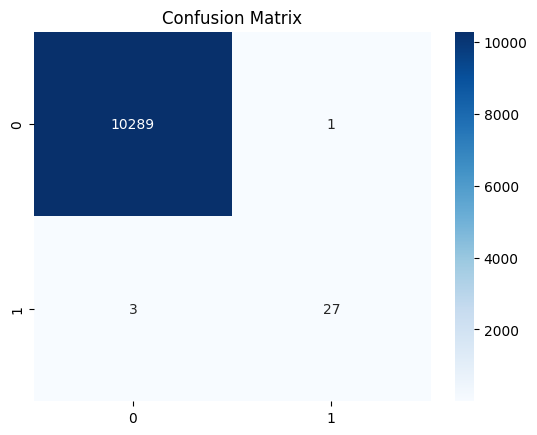

In [7]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10290
         1.0       0.96      0.90      0.93        30

    accuracy                           1.00     10320
   macro avg       0.98      0.95      0.97     10320
weighted avg       1.00      1.00      1.00     10320



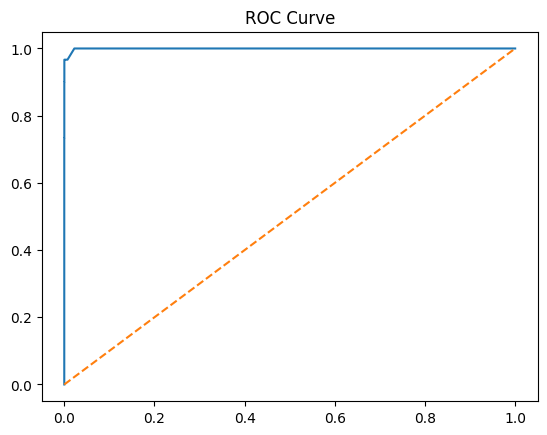

In [9]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

In [10]:
roc_auc_score(y_test, y_prob)

np.float64(0.9994784580498867)